In [102]:
import cuml
%load_ext cuml.accel

The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [103]:
import pandas as pd
import numpy as np
import sklearn

## Feature engineering

In [104]:
train_df = pd.read_csv('./data/train.csv')
test_df = pd.read_csv('./data/test.csv')

In [105]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [106]:
age_median = train_df.groupby(["Pclass", "Sex"])["Age"].agg("median")
fare_median = train_df.groupby(["Pclass", "Sex"])["Fare"].agg("median")

In [107]:
age_median

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

In [108]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

def preprocess(df, age_median, fare_median):
    df = df.copy()
    df.drop(["Cabin", "Ticket", "PassengerId"], axis=1, inplace=True)
    df["Sex_PClass"] = df["Sex"].astype(str) + "_" + df["Pclass"].astype(str)
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    
    df['FareBin'] = pd.qcut(df['Fare'], 4)

    #Age Bins/Buckets using cut or value bins: https://pandas.pydata.org/pandas-docs/stable/generated/pandas.cut.html
    # Fill missing values
    # age_mask = df["Age"].isna()
    # df.loc[age_mask, "Age"] = df.loc[age_mask].set_index(["Pclass", "Sex"]).index.map(age_median)
    # fare_mask = df["Fare"].isna()
    # df.loc[fare_mask, "Fare"] = df.loc[fare_mask].set_index(["Pclass", "Sex"]).index.map(fare_median)
    
    
    # Create tuple index for mapping
    idx = pd.MultiIndex.from_arrays([df["Pclass"], df["Sex"]])
    
    # Fill missing values using passed-in medians
    df["Age"] = df["Age"].fillna(pd.Series(idx.map(age_median), index=df.index))
    df["Fare"] = df["Fare"].fillna(pd.Series(idx.map(fare_median), index=df.index))
    # df["AgeBin"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100], labels=["Child", "Teen", "Adult", "Middle", "Senior"])
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df["Title"] = df["Name"].str.extract(r' ([A-Za-z]+)\.')
    main_titles = ['Mr', 'Mrs', 'Miss', 'Master']
    df["Title"] = df["Title"].map(lambda x: x if x in main_titles else "Rare")

    df['AgeBin'] = pd.cut(df['Age'].astype(int), 5)

    df['IsAlone'] = 1 #initialize to yes/1 is alone
    df['IsAlone'].loc[df['FamilySize'] > 1] = 0
    label = LabelEncoder()  
    df['Sex_Code'] = label.fit_transform(df['Sex'])
    df['Embarked_Code'] = label.fit_transform(df['Embarked'])
    df['Title_Code'] = label.fit_transform(df['Title'])
    df['AgeBin_Code'] = label.fit_transform(df['AgeBin'])
    df['FareBin_Code'] = label.fit_transform(df['FareBin'])
    
    df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
    # df["Title"] = df["Title"].astype("category")
    # df["Embarked"] = df["Embarked"].astype("category")
    # df["Sex_PClass"] = df["Sex_PClass"].astype("category")
    # df = df.drop(["Sex", "Age", "Embarked", "Title", "Fare", "AgeBin", "FareBin", "Sex_PClass"], axis=1)
    
    
    # Drop original columns and concatenate encoded columns
    # df = df.drop(['Name'], axis=1)
    
    
    return df

    
    

## Train

In [109]:
# Train XGBoost model (GPU-accelerated via cuML)
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
# from cuml.naive_bayes import GaussianNB
import cudf
cleaned_train_df = preprocess(train_df, age_median, fare_median)
data1_x_bin = ['Sex_Code','Pclass', 'Embarked_Code', 'Title_Code', 'FamilySize', 'AgeBin_Code', 'FareBin_Code']
X = cleaned_train_df.drop(["Survived"], axis=1)[data1_x_bin]
y = cleaned_train_df["Survived"]

# Convert to cuDF for GPU acceleration
# X_gpu = cudf.DataFrame(X)
# y_gpu = cudf.Series(y)



/tmp/ipykernel_275904/3741927108.py:34: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['IsAlone'].loc[df['FamilySize'] > 1] = 0
/tmp/ipykernel_275904/3741927108.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

In [110]:
X.head()

,Sex_Code,Pclass,Embarked_Code,Title_Code,FamilySize,AgeBin_Code,FareBin_Code
0,1,3,2,2,2,1,0
1,0,1,0,3,2,2,3
2,0,3,2,1,1,1,1
3,0,1,2,3,2,2,3
4,1,3,2,2,1,2,1


In [124]:
# Split for validation
# X_train, X_val, y_train, y_val = train_test_split(X_gpu, y_gpu, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
hyper_param = {'n_estimators': 120, 'max_depth': 8, 'max_leaves': 24, 'learning_rate': 0.10374448010818738, 'subsample': 0.9062292064783252, 'colsample_bytree': 0.7991232614099266, 'reg_alpha': 1.1317657421008092e-08, 'reg_lambda': 2.9919974380229196e-06, 'min_child_weight': 3}

# Create and train model
model = XGBClassifier(
    # n_estimators=100,
    # max_depth=7,
    # max_leaves=128,
    # learning_rate=0.1,
    **hyper_param,
    enable_categorical=True,
    tree_method='hist',
    device='cuda',
    random_state=42,
)


hyper_param = {'max_depth': 12, 'min_samples_split': 13, 'min_samples_leaf': 6, 'max_features': None, 'criterion': 'log_loss', 'splitter': 'best', 'max_leaf_nodes': 59, 'min_impurity_decrease': 0.0017278770327136123}
# hyper_param = {'criterion': 'gini', 'max_depth': 4}
# model = DecisionTreeClassifier(
#     **hyper_param,
#     random_state=42,
#     )
# model = GaussianNB()
# model = LogisticRegression(max_iter=10000)

model.fit(X, y)

# Evaluate - convert cuDF to pandas/numpy for sklearn metrics
# print(f"Validation Accuracy: {model.score(X_val.to_pandas(), y_val.to_numpy()):.4f}")

# Get cross-validated predictions
y_pred_cv = cross_val_predict(model, X, y, cv=5)

# Print the classification report
print(classification_report(y, y_pred_cv, digits=4))

              precision    recall  f1-score   support

           0     0.8271    0.8889    0.8569       549
           1     0.7973    0.7018    0.7465       342

    accuracy                         0.8171       891
   macro avg     0.8122    0.7953    0.8017       891
weighted avg     0.8157    0.8171    0.8145       891



<Axes: >

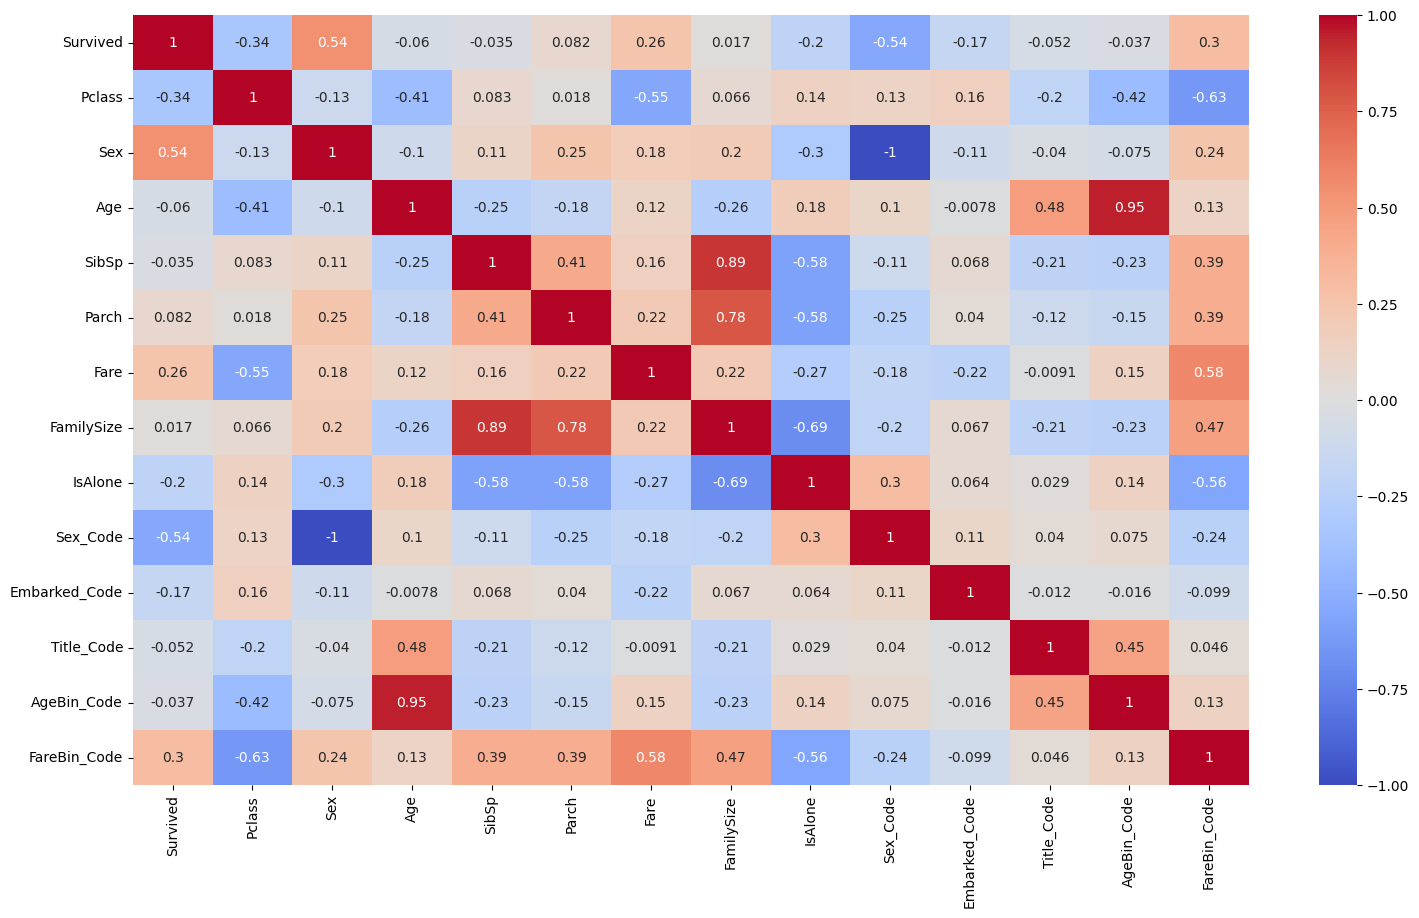

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(18,10))

sns.heatmap(cleaned_train_df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)

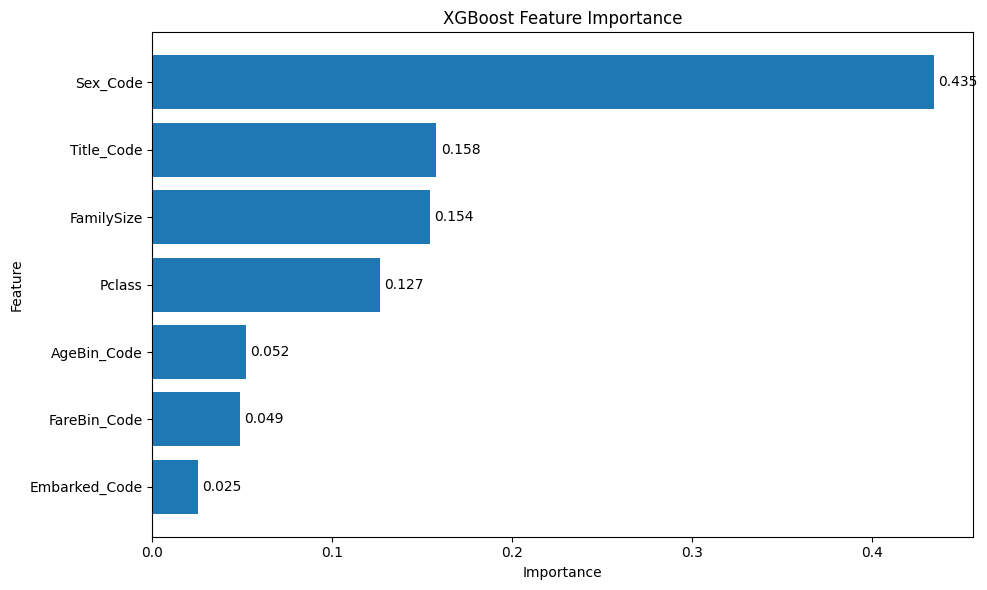

In [126]:
import matplotlib.pyplot as plt

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feature_importance['feature'], feature_importance['importance'])
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

In [114]:
model.fit(X, y)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7991232614099266
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [115]:
cleaned_test_df = preprocess(test_df, age_median, fare_median)
X_test = cleaned_test_df[data1_x_bin]

y_test = model.predict(X_test)

/tmp/ipykernel_275904/3741927108.py:34: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['IsAlone'].loc[df['FamilySize'] > 1] = 0
/tmp/ipykernel_275904/3741927108.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

In [116]:
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": y_test
})

In [117]:
submission.to_csv("./out/submission.csv", index=False)

In [118]:
submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [133]:
submission = pd.read_csv("./submission.csv")

In [134]:
def test(submission):
        

    gt = pd.read_csv("./out/gt.csv")

    # Print the classification report
    print(classification_report(gt["Survived"], submission["Survived"], digits=4))
test(submission)

              precision    recall  f1-score   support

           0     0.8195    0.8385    0.8289       260
           1     0.7237    0.6962    0.7097       158

    accuracy                         0.7847       418
   macro avg     0.7716    0.7673    0.7693       418
weighted avg     0.7833    0.7847    0.7838       418



In [120]:
gt = pd.read_csv("./out/gt.csv")

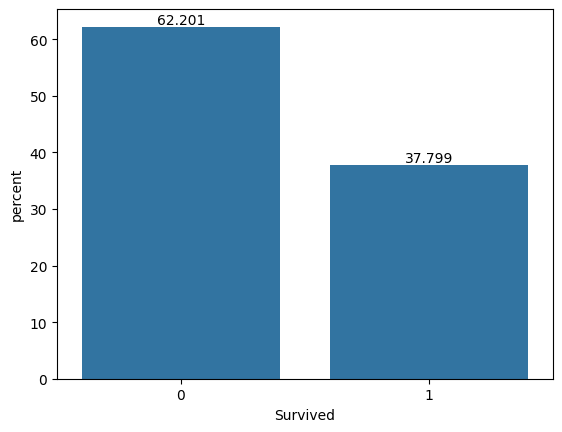

In [121]:
ax = sns.countplot(gt, x=gt["Survived"], stat="percent")

for containter in ax.containers:
    ax.bar_label(containter)

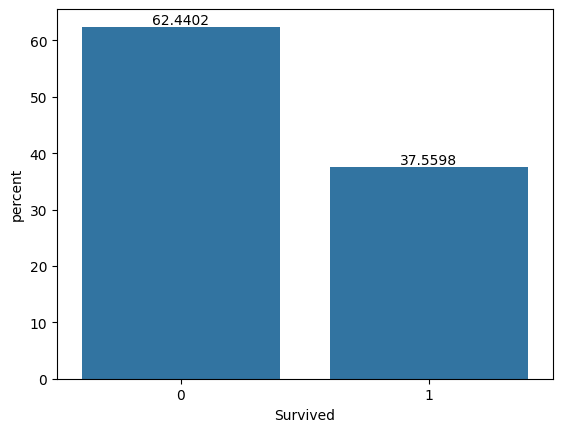

In [123]:
ax = sns.countplot(gt, x=submission["Survived"], stat="percent")

for containter in ax.containers:
    ax.bar_label(containter)

In [122]:
# model_name = type(model).__name__
# !kaggle competitions submit -c titanic -f ./out/submission.csv -m "{model_name}"